In [27]:
pip install emcee

Note: you may need to restart the kernel to use updated packages.


In [28]:
pip install corner

Note: you may need to restart the kernel to use updated packages.


In [61]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset 
from sklearn.metrics import r2_score, mean_absolute_error
import emcee
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cude" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [ ]:
#Testdatan, echte Punkte aus deer Dissertation
real_points = [
    # Point V[f]  f[kHz] T[C°]  K        n      Lifetime
    ("I",   350,   10,   250,   426,   0.0275,   1200), #(Keine direkte Probe, konservative Schätzung aus ähnlichen Bedingungen (350 V / 10 kHz / 250 °C), passt zu No. 20, 36, 37)
    ('II',  350,   4,   220,  592,   0.0441,  2610),
    ('III', 400,   4,   250,  475,   0.0104,   740), #Annäherung an No. 34 (400 V / 10 kHz / 250 °C → 741 h), fast identisch
    ('IV',  400,  10,   220,  546,   0.0468,   741), 
    ('V',   450,   4,   220,  533,   0.0303,   430),
    ('VI',  450,  10,   250,  502,   0.0184,   246),
    ('VII', 400,  10,   250,  546,   0.0468,   657),   # Mittelwert aus No. 21 (573 h) und No. 34 (741 h), beide exakt gleiche Bedingungen
    ('VIII',400,   4,   220,  559,   0.0418,  1922),  # hier genauso, Mittel aus 1586+2258 (No.32 und No. 35)
    ('IX',  350,   4,   250,  535,   0.0482,   246), #ähnlich wie Point VI
    ('X',   350,  10,   220,  547,   0.0323,  1224),
    ]

In [100]:
#potten der Testkurve # Erst die Hilfsfunktion unten ausfühen ipm_model()
#for i in real_points:
    #t = np.linspace(0, i[6], i[6])
    #pdiv = ipm_model(t,i[4],i[5])
    #plt.grid(True)
    #plt.plot(t, pdiv, 'b-', linewidth=1, alpha=0.5, )

In [63]:
#Daten generieren
def generate_imp_curve(K, n, lifetime_hours, noise_std=15, points=1200):
    t = np.linspace(1, lifetime_hours*1.4, points) 
    PDIV_clean = K * t ** (-n)
    PDIV = PDIV_clean + np.random.normal(0, noise_std, points)
    PDIV = np.clip(PDIV, 300, K+100) # Grenzen (realistisch)
    return t, PDIV

# Trainingdaten generieren
train_data = []
for i in range(250):
    #zufällig einen Punkt aus den echten Punkten auswählen, als Basis
    base = real_points[np.random.randint(len(real_points))]
    K = np.random.normal(base[4], 30) #+- 30 um den realen K wert
    n = np.random.normal(base[5], 0.008) #hier auch eine kleine streuung in n
    K = max(K, 400)
    n = max(n, 0.005)
    lifetime = np.random.uniform(200, 3000)

    t, PDIV = generate_imp_curve(K, n, lifetime)
    train_data.append({"id": i, "K": K, "n": n, "lifetime": lifetime, "t": t, "PDIV": PDIV})

# Testdaten (die echten 10 Ponits aus der Dissertation)
test_data = []
for p in real_points: 
    t, PDIV = generate_imp_curve(p[4], p[5], p[6], noise_std=20)
    test_data.append({"point": p[0], "K": p[4], "n": p[5], "lifetime": p[6], "t": t, "PDIV": PDIV})


print(f"Training data: {len(train_data)} synthetische Motoren")
print(f"Test data: {len(test_data)} echte Punkte aus der Dissertation")

Training data: 250 synthetische Motoren
Test data: 10 echte Punkte aus der Dissertation


In [64]:
#test_data[3]

In [65]:
#test_data[3]["t"], test_data[3]["PDIV"]

In [66]:
#plt.plot(test_data[3]["t"], test_data[3]["PDIV"])

In [67]:
#Feature Extractio. PDIV an festen frühen Zeiten 

def extract_early_pdiv(t_vec, pdiv_vec, early_fraction=0.3):
    n= int(early_fraction * len(pdiv_vec))
    early_t = t_vec[:n]
    early_pdiv = pdiv_vec[:n]
    target_times = [100, 200, 300, 400, 500, 600, 700, 800]
    features = []
    for tt in target_times: 
        if early_t[-1]< tt:
            features.append(early_pdiv[-1])
        else:
            idx = np.argmin(np.abs(early_t - tt))
            features.append(early_pdiv[idx])
    return np.array(features)



X_train = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in train_data])
y_train = np.array([m["lifetime"] for m in train_data])

X_test = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in test_data])
y_test = np.array([m["lifetime"] for m in test_data])

#Normalisierung
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_norm = (X_train - X_mean)/ (X_std + 1e-8)
X_test_norm = (X_test - X_mean)/ (X_std + 1e-8)


y_mean, y_std = y_train.mean(), y_train.std()
y_train_norm = (y_train - y_mean)/ y_std
y_test_real = y_test

In [68]:
X_train, y_train.shape, X_test.shape, y_test.shape

(array([[411.86247363, 409.0517271 , 440.26520218, ..., 366.11144016,
         372.80774709, 372.67576713],
        [447.2474216 , 452.44580347, 487.45740725, ..., 454.59479379,
         445.9129219 , 433.39262007],
        [425.91136656, 424.83727008, 374.93625035, ..., 383.09537307,
         383.09537307, 383.09537307],
        ...,
        [402.39125963, 395.86861104, 401.64037626, ..., 394.18480483,
         369.13905978, 381.59801812],
        [498.92529973, 477.62825366, 466.3564169 , ..., 433.82248369,
         445.08451806, 427.84652793],
        [367.4310167 , 379.21666904, 356.91946682, ..., 345.71298965,
         349.58847809, 387.47063712]], shape=(250, 8)),
 (250,),
 (10, 8),
 (10,))

In [69]:
X_test[1], y_test[1]

(array([467.32002169, 511.24386166, 446.88412656, 472.19390776,
        459.0759866 , 457.97691372, 399.2281071 , 434.87980891]),
 np.int64(2610))

In [70]:
#ResNet-CNN 

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
            nn.ReLU(),
            nn.Conv1d(c,c,3,padding=1),
            nn.BatchNorm1d(c)
        )
    
    def forward(self, x):
        return nn.ReLU()(self.net(x) + x)

class ResNetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1,64,7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        self.blocks = nn.Sequential(
            ResBlock(64), ResBlock(64),
            nn.Conv1d(64,128,3, padding=1),
            nn.ReLU(),
            ResBlock(128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128,1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.stem(x)
        x = self.blocks(x).flatten(1)
        return self.fc(x).squeeze(-1)

In [72]:
model = ResNetCNN().to(device)
opt = optim.Adam(model.parameters(), lr=0.0015, weight_decay=1e-5)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_norm), torch.FloatTensor(y_train_norm)),
batch_size=32, shuffle=True,)

#Model mit den bestem Loss speichern
best_loss = float("inf")
best_model_state = None
best_epoch = -1

#Model trainieren
model.train()
for epoch in range(600):
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_model_state = model.state_dict().copy()
        best_epoch = epoch
        print(f"Best model, Epoch: {epoch:3d}, Loss: {epoch_loss:.6f} saved")
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:3d}, Loss: {epoch_loss:.6f}")

#Best Model laden und speichern
print(f"Trainin finished, best model saved, Epoch: {best_epoch:3d}, Loss: {best_loss:.6f}")
model.load_state_dict(best_model_state)

#speichern
import os
os.makedirs("saved_models", exist_ok=True)
torch.save({
        'epoch': best_epoch,
    'model_state_dict': best_model_state,
    'loss': best_loss,
    'X_mean': X_mean,
    'X_std': X_std,
    'y_mean': y_mean,
    'y_std': y_std
}, "saved_models/res_cnn_motor_best.pth")

print("Model saved")


#Evaluationsteil 
model.eval()
with torch.no_grad():
    pred_norm = model(torch.FloatTensor(X_test_norm).to(device)).cpu().numpy()
    pred_life = pred_norm * y_std + y_mean


r2_s1 = r2_score(y_test_real, pred_life)
mae_s1 = mean_absolute_error(y_test_real, pred_life)
print(f"Auf den echten 10 Punkten aus der Dissertation")
print(f"R2: {r2_s1:.4f}, MAE: {mae_s1:.1f}")



Best model, Epoch:   0, Loss: 1.209608 saved
Epoch:   0, Loss: 1.209608
Best model, Epoch:   1, Loss: 0.746848 saved
Best model, Epoch:   2, Loss: 0.655719 saved
Best model, Epoch:   3, Loss: 0.492611 saved
Best model, Epoch:   4, Loss: 0.390602 saved
Best model, Epoch:   5, Loss: 0.254451 saved
Best model, Epoch:   6, Loss: 0.251823 saved
Best model, Epoch:   7, Loss: 0.225262 saved
Best model, Epoch:   8, Loss: 0.134433 saved
Best model, Epoch:   9, Loss: 0.133453 saved
Best model, Epoch:  10, Loss: 0.101998 saved
Epoch:  10, Loss: 0.101998
Best model, Epoch:  11, Loss: 0.057592 saved
Best model, Epoch:  19, Loss: 0.045763 saved
Best model, Epoch:  20, Loss: 0.036988 saved
Epoch:  20, Loss: 0.036988
Best model, Epoch:  23, Loss: 0.034597 saved
Best model, Epoch:  25, Loss: 0.030506 saved
Epoch:  30, Loss: 0.049072
Best model, Epoch:  40, Loss: 0.028452 saved
Epoch:  40, Loss: 0.028452
Best model, Epoch:  42, Loss: 0.025810 saved
Best model, Epoch:  43, Loss: 0.021701 saved
Best model

In [79]:
# Bayesian Stage 2


def ipm_model(t, K, n):
    return K * t **(-n)

def log_likelihood(theta, t_obs, pdiv_obs, sigma=15.0):
    K, log_n = theta 
    n = np.exp(log_n) # n > 0
    if K < 300 or K >800 or n < 0.001 or n > 0.1:
        return -np.inf
    model_pred = ipm_model(t_obs, K, n)
    residual = pdiv_obs - model_pred
    return -0.5 * np.sum(residual**2 / sigma**2 + np.log(2*np.pi*sigma**2))

def log_prior(theta):
    K, log_n = theta
    n = np.exp(log_n)
    if 400 < K < 700 and -6.0 < log_n < -2.0: # n zwischen 0.0025 und 0.135
        return 0.0
    return -np.inf

def log_posterior(theta, t_obs, pdiv_obs):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t_obs, pdiv_obs)

Stage 2 für Point II, echte Lebensdauer: 2610h
Accepted 6400 samples, K = 593.5 ± 5.6, n = 0.04500 ± 1.03547


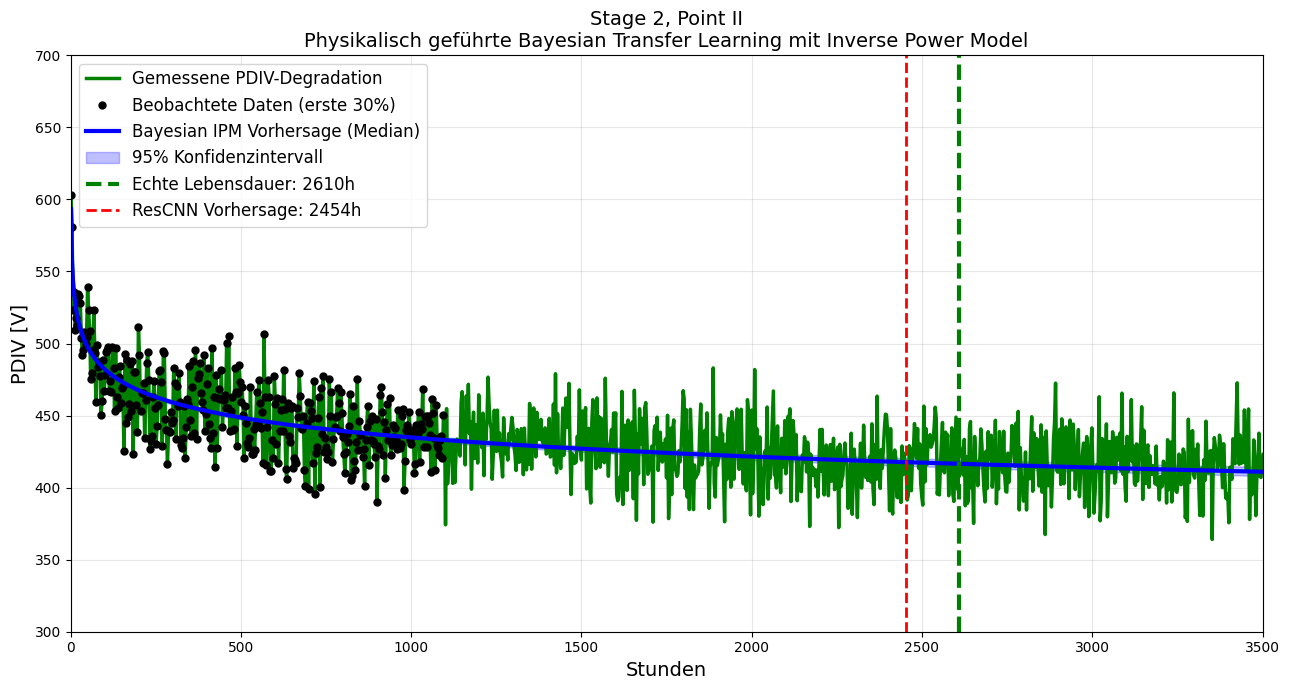

 R² stage 2: 0.9997
 MAE: 0.10 V


In [101]:
#mean_curve_list = [] # Beispiel: Point II (bester Fit in der Dissertation)
#for i in range(0,10):
idx = 1 #hier ändern, um verschiedene Punkte zu testen (10 Motoren)
motor = test_data[idx]
t_full = motor['t']
pdiv_full = motor['PDIV']
true_life = motor['lifetime']
cnn_life = pred_life[idx]

obs_n = int(0.3 * len(t_full))
t_obs = t_full[:obs_n]
pdiv_obs = pdiv_full[:obs_n]

print(f"Stage 2 für Point {motor['point']}, echte Lebensdauer: {true_life}h")

# MCMC
ndim, nwalkers = 2, 64
# Startwerte in der Nähe des wahren Werts (für schnelle Konvergenz)
p0 = np.array([580, np.log(0.044)]) + 0.05 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t_obs, pdiv_obs))
sampler.run_mcmc(p0, 6000, progress=False)
samples = sampler.get_chain(discard=3000, thin=30, flat=True)

print(f"Accepted {len(samples)} samples, K = {np.mean(samples[:,0]):.1f} ± {np.std(samples[:,0]):.1f}, "
        f"n = {np.exp(np.mean(samples[:,1])):.5f} ± {np.exp(np.std(samples[:,1])):.5f}")

# Vorhersage
n_samples = 150
curves = []
for i in np.random.randint(len(samples), size=n_samples):
    K, log_n = samples[i]
    curves.append(ipm_model(t_full, K, np.exp(log_n)))
curves = np.array(curves)

mean_curve = np.median(curves, axis=0)  # Median ist robuster als Mean
lower = np.percentile(curves, 2.5, axis=0)
upper = np.percentile(curves, 97.5, axis=0)

#mean_curve_list.append(mean_curve)
# Plot
plt.figure(figsize=(13, 7))
plt.plot(t_full, pdiv_full, 'g-', linewidth=2.5, label='Gemessene PDIV-Degradation')
plt.plot(t_obs, pdiv_obs, 'ko', markersize=5, label='Beobachtete Daten (erste 30%)')
plt.plot(t_full, mean_curve, 'b-', linewidth=3, label='Bayesian IPM Vorhersage (Median)')
plt.fill_between(t_full, lower, upper, color='blue', alpha=0.25, label='95% Konfidenzintervall')
plt.axvline(true_life, color='green', linestyle='--', linewidth=3, label=f'Echte Lebensdauer: {true_life}h')
plt.axvline(cnn_life, color='red', linestyle='--', linewidth=2, label=f'ResCNN Vorhersage: {cnn_life:.0f}h')
plt.xlabel('Stunden', fontsize=14)
plt.ylabel('PDIV [V]', fontsize=14)
plt.title(f'Stage 2, Point {motor['point']}\nPhysikalisch geführte Bayesian Transfer Learning mit Inverse Power Model', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 3500)
plt.ylim(300, 700)
plt.tight_layout()
plt.show()



from scipy.optimize import curve_fit  
# das IPM direkt auf die beobachteten Daten fitten
popt, _ = curve_fit(ipm_model, t_obs, pdiv_obs, p0=[600, 0.04], bounds=([300, 0.001], [800, 0.1]))

# Berechne den wahren Fit 
true_fit_curve = ipm_model(t_full, *popt)

#  vergleichen,  (aber nur die geglätteten Kurven)
r2_correct = r2_score(true_fit_curve[obs_n:], mean_curve[obs_n:])
mae_correct = mean_absolute_error(true_fit_curve[obs_n:], mean_curve[obs_n:])

print(f" R² stage 2: {r2_correct:.4f}")
print(f" MAE: {mae_correct:.2f} V")